In [1]:
import sys
print(sys.executable)

/opt/miniconda3/envs/pontia-ml/bin/python


In [3]:
pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-macosx_13_0_arm64.whl (46.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install -U scikit-image

ERROR: Could not find a version that satisfies the requirement scikit-imagepip (from versions: none)
ERROR: No matching distribution found for scikit-imagepip
Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importamos sys para comprobar qué Python está usando el notebook
import sys

# Path nos permite trabajar con rutas de carpetas y archivos de forma más segura
from pathlib import Path

# Pandas se usa para leer y trabajar con archivos CSV
import pandas as pd

# OpenCV se usará después para leer imágenes
import cv2

# Matplotlib se usará después para visualizar imágenes
import matplotlib.pyplot as plt

# Numpy

import numpy as np

In [2]:
pwd

'/Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/4_ML_DL/TFM_companeros_estructura/notebooks'

In [3]:
#Vamos a crear un df con 1000 imagenes y vemos cómo funciona esto
df_imagenes_crudo=pd.read_csv("../../../archive/raw_dataset.csv")
df_imagenes_crudo

#Generamos el df de 1000 imagenes
#df_1000_imagenes=df_imagenes_crudo.sample(n=1000,weights="percent")

,Unnamed: 0,0,fruta,percent
0,0,Apple/Apple E/Apple E08152.png,Apple,15.855197
1,1,Apple/Apple E/Apple E117.png,Apple,15.855197
2,2,Apple/Apple E/Apple E103.png,Apple,15.855197
3,3,Apple/Apple E/Apple Ee01601.png,Apple,15.855197
4,4,Apple/Apple E/Apple E05112.png,Apple,15.855197
...,...,...,...,...
70546,70546,Tomatoes/Tamotoes00485.png,Tomatoes,3.077207
70547,70547,Tomatoes/Tamotoes001605.png,Tomatoes,3.077207
70548,70548,Tomatoes/Tamotoes001611.png,Tomatoes,3.077207
70549,70549,Tomatoes/Tamotoes001177.png,Tomatoes,3.077207


In [8]:
df_1000_imagenes

,Unnamed: 0,0,fruta,percent
33080,33080,Guava/Guava total/Guava。756 resized.png,Guava,27.921645
32098,32098,Guava/Guava total/Guava。528.png,Guava,27.921645
31891,31891,Guava/Guava total/Guava。374 resized.jpg,Guava,27.921645
12111,12111,Banana/Banana0762.png,Banana,4.290513
3505,3505,Apple/Apple A/Apple 230.png,Apple,15.855197
...,...,...,...,...
28552,28552,Guava/Guava total/Guava。2144.png,Guava,27.921645
34985,34985,Guava/guava A/ene05221.png,Guava,27.921645
25731,25731,Guava/Guava total/Guava。1078 resized.jpg,Guava,27.921645
6161,6161,Apple/Apple F/Apple F361.png,Apple,15.855197


In [7]:
df_1000_imagenes.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 33080 to 32585
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   0           1000 non-null   str    
 2   fruta       1000 non-null   str    
 3   percent     1000 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 39.1 KB


In [5]:
# ==============================
# BLOQUE 1 - Validar entorno y leer sample_1000
# ==============================

# Importamos sys para comprobar qué Python está usando el notebook
import sys

# Path nos permite trabajar con rutas de carpetas y archivos de forma más segura
from pathlib import Path

# Pandas se usa para leer y trabajar con archivos CSV
import pandas as pd

# OpenCV se usará después para leer imágenes
import cv2

# Matplotlib se usará después para visualizar imágenes
import matplotlib.pyplot as plt

# Numpy

import numpy as np


# Mostramos qué Python está usando el notebook
# Esto debe apuntar al entorno .venv del proyecto TFM
print("Python usado por el notebook:")
print(sys.executable)


# Definimos la ruta del CSV pequeño de prueba
# Como estamos dentro de notebooks/, usamos ../ para subir una carpeta hacia TFM/
#sample_csv = Path("../data/sample_100/sample_100.csv")

# Definimos la carpeta base donde están las imágenes reales
base_dir = Path("../../../archive/")


# Leemos el CSV sample_100
#df = pd.read_csv(sample_csv)
df=df_imagenes_crudo

# Mostramos información básica del sample
print("\nFilas del sample:", len(df))
print("Número de clases:", df["fruta"].nunique())

# Mostramos las primeras filas para comprobar que se ha leído bien


Python usado por el notebook:
/opt/miniconda3/envs/pontia-ml/bin/python

Filas del sample: 70551
Número de clases: 15


,Unnamed: 0,0,fruta,percent
0,0,Apple/Apple E/Apple E08152.png,Apple,15.855197
1,1,Apple/Apple E/Apple E117.png,Apple,15.855197
2,2,Apple/Apple E/Apple E103.png,Apple,15.855197
3,3,Apple/Apple E/Apple Ee01601.png,Apple,15.855197
4,4,Apple/Apple E/Apple E05112.png,Apple,15.855197


Etiqueta: Apple
Ruta relativa: Apple/Apple E/Apple E08152.png
Ruta completa: ../../../archive/Apple/Apple E/Apple E08152.png
Shape original: (258, 320, 3)


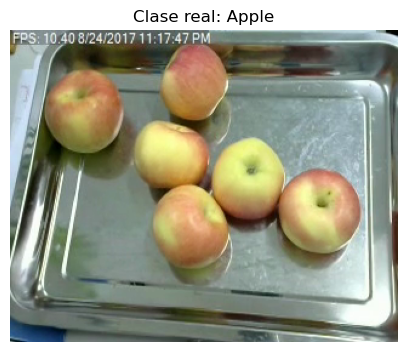

In [7]:
# ==============================
# BLOQUE 2 - Cargar y visualizar una imagen del sample
# ==============================

#generamos la variable df
df=df_imagenes_crudo

# Seleccionamos la primera fila del sample_100
fila = df.iloc[0]

# Obtenemos la ruta relativa de la imagen desde la columna "0"
ruta_relativa = fila["0"]

# Obtenemos la etiqueta real de la imagen
etiqueta = fila["fruta"]

# Construimos la ruta completa de la imagen
ruta_imagen = base_dir / ruta_relativa

# Mostramos información básica
print("Etiqueta:", etiqueta)
print("Ruta relativa:", ruta_relativa)
print("Ruta completa:", ruta_imagen)

# Leemos la imagen con OpenCV
# IMPORTANTE: OpenCV lee por defecto en formato BGR, no RGB
img_bgr = cv2.imread(str(ruta_imagen))

# Comprobamos que OpenCV ha podido leer la imagen
if img_bgr is None:
    raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")

# Mostramos la forma de la imagen
# Formato: alto, ancho, canales
print("Shape original:", img_bgr.shape)

# Convertimos de BGR a RGB para visualizar correctamente con matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostramos la imagen
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Clase real: {etiqueta}")
plt.axis("off")
plt.show()

Shape RGB original: (258, 320, 3)
Shape gris original: (258, 320)
Shape RGB redimensionada: (128, 128, 3)
Shape gris redimensionada: (128, 128)


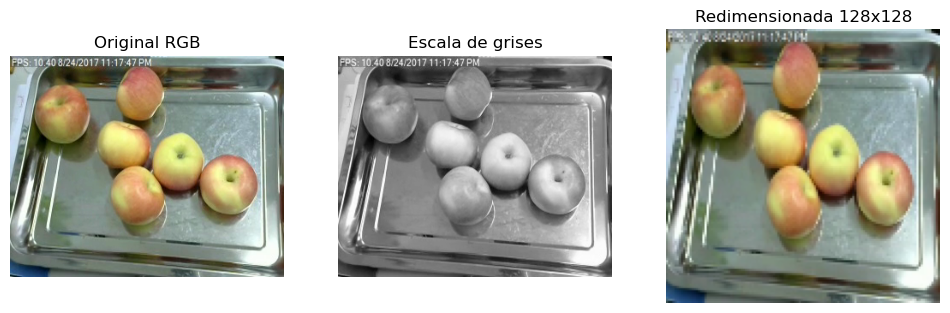

In [8]:
# ==============================
# BLOQUE 3 - Visualizar imagen original, gris y redimensionada
# ==============================

# Definimos el tamaño común al que queremos llevar las imágenes
# Este tamaño será importante porque los modelos necesitan vectores comparables
nuevo_tamano = (128, 128)  # (ancho, alto)

# Convertimos la imagen BGR original a RGB para verla correctamente
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convertimos la imagen BGR original a escala de grises
# Esta versión será útil después para HOG y LBP
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Redimensionamos la imagen RGB a un tamaño común
# cv2.resize recibe el tamaño como (ancho, alto)
img_rgb_resized = cv2.resize(img_rgb, nuevo_tamano)

# Redimensionamos también la imagen en gris
img_gray_resized = cv2.resize(img_gray, nuevo_tamano)

# Mostramos información de tamaños
print("Shape RGB original:", img_rgb.shape)
print("Shape gris original:", img_gray.shape)
print("Shape RGB redimensionada:", img_rgb_resized.shape)
print("Shape gris redimensionada:", img_gray_resized.shape)

# Creamos una figura con varias imágenes para comparar visualmente
plt.figure(figsize=(12, 4))

# Imagen original en color
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.axis("off")

# Imagen en escala de grises
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

# Imagen redimensionada
plt.subplot(1, 3, 3)
plt.imshow(img_rgb_resized)
plt.title("Redimensionada 128x128")
plt.axis("off")

plt.show()

------

Tamaño vector Histograma RGB: (96,)
Primeros valores del vector RGB:
[0.00189209 0.00140381 0.00311279 0.00372314 0.00610352 0.01422119
 0.01867676 0.02618408 0.02593994 0.02410889]


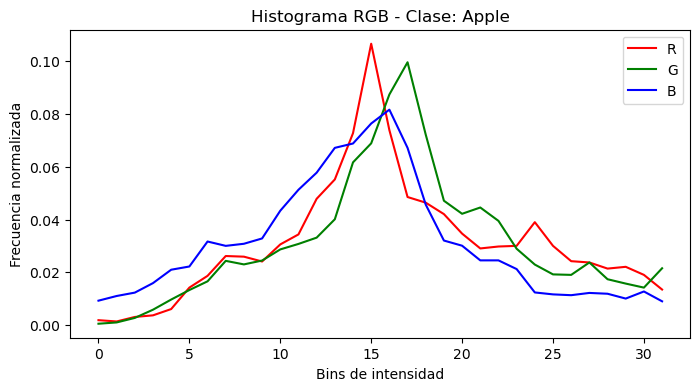

In [9]:
# ==============================
# BLOQUE 4 - Extraer Histograma RGB
# ==============================

# El histograma RGB captura la distribución de colores de la imagen.
# Trabajaremos con la imagen RGB redimensionada a 128x128.
# Esto permite que todas las imágenes tengan el mismo tamaño antes de extraer características.

# Número de "bins" por canal.
# Cuantos más bins, más detalle de color, pero también más variables.
bins = 32

# Calculamos el histograma del canal R.
# En img_rgb_resized, el canal 0 corresponde a Red.
hist_r = cv2.calcHist(
    [img_rgb_resized],   # imagen de entrada
    [0],                 # canal 0 = R
    None,                # sin máscara, usamos toda la imagen
    [bins],              # número de bins
    [0, 256]             # rango de valores posibles en imágenes de 8 bits
)

# Calculamos el histograma del canal G.
# En img_rgb_resized, el canal 1 corresponde a Green.
hist_g = cv2.calcHist(
    [img_rgb_resized],
    [1],
    None,
    [bins],
    [0, 256]
)

# Calculamos el histograma del canal B.
# En img_rgb_resized, el canal 2 corresponde a Blue.
hist_b = cv2.calcHist(
    [img_rgb_resized],
    [2],
    None,
    [bins],
    [0, 256]
)

# Normalizamos los histogramas.
# Así evitamos que el histograma dependa demasiado del número total de píxeles.
# Aunque todas las imágenes son 128x128, normalizar sigue siendo buena práctica.
hist_r = hist_r / hist_r.sum()
hist_g = hist_g / hist_g.sum()
hist_b = hist_b / hist_b.sum()

# Convertimos cada histograma a vector plano.
hist_r = hist_r.flatten()
hist_g = hist_g.flatten()
hist_b = hist_b.flatten()

# Concatenamos los tres canales en un único vector de características de color.
# Si usamos 32 bins por canal:
# R = 32 valores
# G = 32 valores
# B = 32 valores
# Total = 96 características de color
feature_rgb = np.concatenate([hist_r, hist_g, hist_b])

# Mostramos el tamaño del vector final RGB
print("Tamaño vector Histograma RGB:", feature_rgb.shape)
print("Primeros valores del vector RGB:")
print(feature_rgb[:10])

# Visualizamos los histogramas de color
plt.figure(figsize=(8, 4))

plt.plot(hist_r, label="R", color="red")
plt.plot(hist_g, label="G", color="green")
plt.plot(hist_b, label="B",color="blue")

plt.title(f"Histograma RGB - Clase: {etiqueta}")
plt.xlabel("Bins de intensidad")
plt.ylabel("Frecuencia normalizada")
plt.legend()
plt.show()

El histograma RGB captura la distribución global de color de la imagen, pero no conserva la posición espacial de esos colores. Por tanto, puede confundir frutas con colores parecidos aunque tengan formas diferentes.

--------------

Tamaño vector HOG: (8100,)
Primeros valores del vector HOG:
[0.25615595 0.0804393  0.21138769 0.20316855 0.26519598 0.11161305
 0.0686219  0.19834297 0.17365863 0.26519598]


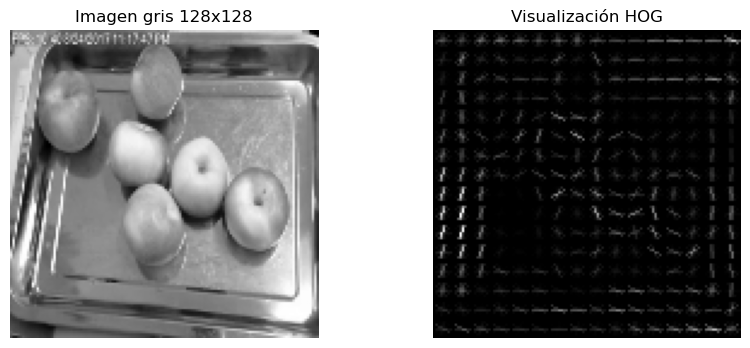

In [10]:
# ==============================
# BLOQUE 5 - Extraer características HOG
# ==============================

# Importamos HOG desde scikit-image
# HOG significa Histogram of Oriented Gradients
# Sirve para capturar forma, bordes y contornos de la imagen
from skimage.feature import hog

# HOG normalmente se calcula sobre una imagen en escala de grises
# Usamos la imagen gris redimensionada que ya creamos antes: img_gray_resized

# Extraemos características HOG
# visualize=True nos devuelve también una imagen visual para entender los bordes detectados
feature_hog, hog_image = hog(
    img_gray_resized,              # imagen en escala de grises
    orientations=9,                # número de direcciones/orientaciones de gradiente
    pixels_per_cell=(8, 8),        # tamaño de cada celda en píxeles
    cells_per_block=(2, 2),        # agrupación de celdas para normalización
    block_norm="L2-Hys",           # normalización habitual en HOG
    visualize=True,                # devuelve imagen HOG para visualizar
    feature_vector=True            # devuelve el resultado como vector plano
)

# Mostramos el tamaño del vector HOG
print("Tamaño vector HOG:", feature_hog.shape)

# Mostramos los primeros valores del vector HOG
print("Primeros valores del vector HOG:")
print(feature_hog[:10])

# Visualizamos la imagen original en gris y la representación HOG
plt.figure(figsize=(10, 4))

# Imagen gris redimensionada
plt.subplot(1, 2, 1)
plt.imshow(img_gray_resized, cmap="gray")
plt.title("Imagen gris 128x128")
plt.axis("off")

# Imagen HOG
plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap="gray")
plt.title("Visualización HOG")
plt.axis("off")

plt.show()

Los descriptores clásicos como HOG pueden capturar no solo la forma de la fruta, sino también bordes del fondo o del soporte donde aparece la imagen.

--------

Tamaño vector LBP: (10,)
Valores del vector LBP:
[0.04266357 0.08410645 0.04107666 0.11419678 0.26312256 0.13464355
 0.06726074 0.081604   0.06921387 0.10211182]


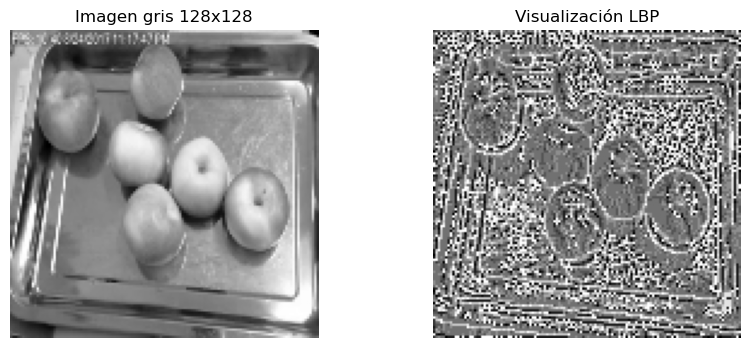

In [11]:
# ==============================
# BLOQUE 6 - Extraer características LBP
# ==============================

# Importamos Local Binary Pattern desde scikit-image
# LBP sirve para capturar patrones de textura en la imagen
from skimage.feature import local_binary_pattern

# Parámetros principales de LBP
# P = número de puntos vecinos que se comparan alrededor de cada píxel
# R = radio de distancia respecto al píxel central
# method="uniform" reduce el número de patrones posibles y hace el descriptor más compacto
P = 8
R = 1
method = "uniform"

# Calculamos LBP sobre la imagen en escala de grises redimensionada
# Usamos img_gray_resized porque LBP trabaja sobre intensidad, no sobre RGB
lbp_image = local_binary_pattern(
    img_gray_resized,  # imagen gris 128x128
    P=P,               # número de vecinos
    R=R,               # radio
    method=method      # método uniforme
)

# Con method="uniform", los valores posibles de LBP van aproximadamente de 0 a P + 2
# Por eso usamos bins = P + 2
n_bins = P + 2

# Calculamos un histograma de la imagen LBP
# Este histograma resume cuántas veces aparece cada patrón de textura
hist_lbp, _ = np.histogram(
    lbp_image.ravel(),       # convertimos la imagen LBP en un vector plano
    bins=n_bins,             # número de bins para los patrones LBP
    range=(0, n_bins),       # rango de valores esperados
    density=True             # normalizamos el histograma
)

# Convertimos el histograma LBP en vector de características
feature_lbp = hist_lbp.astype("float32")

# Mostramos el tamaño del vector LBP
print("Tamaño vector LBP:", feature_lbp.shape)

# Mostramos los primeros valores del vector LBP
print("Valores del vector LBP:")
print(feature_lbp)

# Visualizamos imagen gris y representación LBP
plt.figure(figsize=(10, 4))

# Imagen gris original redimensionada
plt.subplot(1, 2, 1)
plt.imshow(img_gray_resized, cmap="gray")
plt.title("Imagen gris 128x128")
plt.axis("off")

# Imagen LBP
plt.subplot(1, 2, 2)
plt.imshow(lbp_image, cmap="gray")
plt.title("Visualización LBP")
plt.axis("off")

plt.show()

LBP captura patrones locales de textura en la imagen, lo que puede ayudar a distinguir frutas con superficies diferentes. Sin embargo, también puede recoger textura del fondo, brillos, ruido o elementos externos como la bandeja si la fruta no está bien aislada.

------

In [12]:
# ==============================
# BLOQUE 7 - Concatenar RGB + HOG + LBP
# ==============================

# Hasta ahora tenemos tres vectores:
# feature_rgb  -> características de color
# feature_hog  -> características de forma y bordes
# feature_lbp  -> características de textura

print("Tamaño RGB:", feature_rgb.shape)
print("Tamaño HOG:", feature_hog.shape)
print("Tamaño LBP:", feature_lbp.shape)

# Concatenamos los tres vectores en un único vector final
# Este será el vector completo que representa la imagen para ML clásico
feature_final = np.concatenate([
    feature_rgb,
    feature_hog,
    feature_lbp
])

# Mostramos el tamaño total del vector final
print("\nTamaño vector final:", feature_final.shape)

# Mostramos los primeros valores del vector final
print("Primeros valores del vector final:")
print(feature_final[:10])

Tamaño RGB: (96,)
Tamaño HOG: (8100,)
Tamaño LBP: (10,)

Tamaño vector final: (8206,)
Primeros valores del vector final:
[0.00189209 0.00140381 0.00311279 0.00372314 0.00610352 0.01422119
 0.01867676 0.02618408 0.02593994 0.02410889]


Al concatenar RGB, HOG y LBP se obtiene un vector final que combina color, forma y textura. No obstante, HOG aporta muchas más variables que el resto de descriptores, por lo que será necesario aplicar escalado y reducción de dimensionalidad antes de entrenar modelos como SVM o KNN.

-----------

In [13]:
# ==============================
# BLOQUE 8 - Función reutilizable para extraer RGB + HOG + LBP
# ==============================

def extraer_caracteristicas_imagen(ruta_imagen, size=(128, 128), bins_rgb=32):
    """
    Extrae características clásicas de una imagen:
    - Histograma RGB: color
    - HOG: forma y bordes
    - LBP: textura
    
    Parámetros:
    ruta_imagen: ruta completa de la imagen
    size: tamaño común al que se redimensiona la imagen
    bins_rgb: número de bins por canal RGB
    
    Devuelve:
    vector_final: vector numérico con RGB + HOG + LBP
    """
    
    # Leemos la imagen con OpenCV
    # OpenCV lee por defecto en formato BGR
    img_bgr = cv2.imread(str(ruta_imagen))
    
    # Si la imagen no se puede leer, lanzamos error
    if img_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")
    
    # Convertimos de BGR a RGB para el histograma de color
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Convertimos de BGR a escala de grises para HOG y LBP
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Redimensionamos ambas versiones a un tamaño común
    img_rgb_resized = cv2.resize(img_rgb, size)
    img_gray_resized = cv2.resize(img_gray, size)
    
    # ------------------------------
    # 1. Histograma RGB
    # ------------------------------
    
    hist_r = cv2.calcHist([img_rgb_resized], [0], None, [bins_rgb], [0, 256])
    hist_g = cv2.calcHist([img_rgb_resized], [1], None, [bins_rgb], [0, 256])
    hist_b = cv2.calcHist([img_rgb_resized], [2], None, [bins_rgb], [0, 256])
    
    # Normalizamos cada canal para trabajar con proporciones
    hist_r = hist_r / hist_r.sum()
    hist_g = hist_g / hist_g.sum()
    hist_b = hist_b / hist_b.sum()
    
    # Convertimos a vectores planos
    hist_r = hist_r.flatten()
    hist_g = hist_g.flatten()
    hist_b = hist_b.flatten()
    
    # Concatenamos los tres canales RGB
    feature_rgb = np.concatenate([hist_r, hist_g, hist_b])
    
    # ------------------------------
    # 2. HOG
    # ------------------------------
    
    feature_hog = hog(
        img_gray_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )
    
    # ------------------------------
    # 3. LBP
    # ------------------------------
    
    P = 8
    R = 1
    method = "uniform"
    
    lbp_image = local_binary_pattern(
        img_gray_resized,
        P=P,
        R=R,
        method=method
    )
    
    n_bins = P + 2
    
    hist_lbp, _ = np.histogram(
        lbp_image.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )
    
    feature_lbp = hist_lbp.astype("float32")
    
    # ------------------------------
    # 4. Concatenación final
    # ------------------------------
    
    vector_final = np.concatenate([
        feature_rgb,
        feature_hog,
        feature_lbp
    ])
    
    return vector_final

In [16]:
#Creamos una lista con imagenes que son None

lista_imagenes_no_validas=[]

for _, fila in tqdm(df.iterrows(), total=len(df)):
    
    # Obtenemos la ruta relativa de la imagen
    ruta_relativa = fila["0"]
    
    # Obtenemos la etiqueta real de la fruta
    etiqueta = fila["fruta"]
    
    # Construimos la ruta completa de la imagen
    ruta_imagen = base_dir / ruta_relativa
    
    img_bgr = cv2.imread(str(ruta_imagen))
    
    # Si la imagen no se puede leer, lanzamos error
    if img_bgr is None:
        lista_imagenes_no_validas.append(ruta_imagen)


100%|███████████████████████████████████| 70551/70551 [03:45<00:00, 312.20it/s]


In [17]:
lista_imagenes_no_validas

[PosixPath('../../../archive/Apple/.DS_Store'),
 PosixPath('../../../archive/Guava/.DS_Store')]

In [18]:
df_copia=df.copy()

In [19]:
df_copia.columns

Index(['Unnamed: 0', '0', 'fruta', 'percent'], dtype='str')

In [31]:
df_copia.head(5)

,Unnamed: 0,0,fruta,percent
0,0,Apple/Apple E/Apple E08152.png,Apple,15.855197
1,1,Apple/Apple E/Apple E117.png,Apple,15.855197
2,2,Apple/Apple E/Apple E103.png,Apple,15.855197
3,3,Apple/Apple E/Apple Ee01601.png,Apple,15.855197
4,4,Apple/Apple E/Apple E05112.png,Apple,15.855197


In [32]:
lista_imagenes_no_validas_corregidas=["Apple/.DS_Store","Guava/.DS_Store"]

In [33]:
df_copia=df_copia[~df_copia["0"].isin(lista_imagenes_no_validas_corregidas)]
print(len(df_copia),len(df))

#df = df[~df["columna"].isin(lista)]

70549 70551


In [26]:
# ==============================
# BLOQUE 8' - Función reutilizable para extraer RGB + HOG + LBP con try-except
# ==============================

def extraer_caracteristicas_imagen(ruta_imagen, size=(128, 128), bins_rgb=32):
    """
    Extrae características clásicas de una imagen:
    - Histograma RGB: color
    - HOG: forma y bordes
    - LBP: textura
    
    Parámetros:
    ruta_imagen: ruta completa de la imagen
    size: tamaño común al que se redimensiona la imagen
    bins_rgb: número de bins por canal RGB
    
    Devuelve:
    vector_final: vector numérico con RGB + HOG + LBP
    """
    
    # Leemos la imagen con OpenCV
    # OpenCV lee por defecto en formato BGR
    img_bgr = cv2.imread(str(ruta_imagen))
    
    # Si la imagen no se puede leer, lanzamos error
    if img_bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {ruta_imagen}")
    
    # Convertimos de BGR a RGB para el histograma de color
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Convertimos de BGR a escala de grises para HOG y LBP
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Redimensionamos ambas versiones a un tamaño común
    img_rgb_resized = cv2.resize(img_rgb, size)
    img_gray_resized = cv2.resize(img_gray, size)
    
    # ------------------------------
    # 1. Histograma RGB
    # ------------------------------
    
    hist_r = cv2.calcHist([img_rgb_resized], [0], None, [bins_rgb], [0, 256])
    hist_g = cv2.calcHist([img_rgb_resized], [1], None, [bins_rgb], [0, 256])
    hist_b = cv2.calcHist([img_rgb_resized], [2], None, [bins_rgb], [0, 256])
    
    # Normalizamos cada canal para trabajar con proporciones
    hist_r = hist_r / hist_r.sum()
    hist_g = hist_g / hist_g.sum()
    hist_b = hist_b / hist_b.sum()
    
    # Convertimos a vectores planos
    hist_r = hist_r.flatten()
    hist_g = hist_g.flatten()
    hist_b = hist_b.flatten()
    
    # Concatenamos los tres canales RGB
    feature_rgb = np.concatenate([hist_r, hist_g, hist_b])
    
    # ------------------------------
    # 2. HOG
    # ------------------------------
    
    feature_hog = hog(
        img_gray_resized,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )
    
    # ------------------------------
    # 3. LBP
    # ------------------------------
    
    P = 8
    R = 1
    method = "uniform"
    
    lbp_image = local_binary_pattern(
        img_gray_resized,
        P=P,
        R=R,
        method=method
    )
    
    n_bins = P + 2
    
    hist_lbp, _ = np.histogram(
        lbp_image.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )
    
    feature_lbp = hist_lbp.astype("float32")
    
    # ------------------------------
    # 4. Concatenación final
    # ------------------------------
    
    vector_final = np.concatenate([
        feature_rgb,
        feature_hog,
        feature_lbp
    ])
    
    return vector_final

In [27]:
# Probamos la función con la imagen actual
vector_prueba = extraer_caracteristicas_imagen(ruta_imagen)

print("Tamaño del vector extraído:", vector_prueba.shape)
print("Primeros valores:")
print(vector_prueba[:10])

Tamaño del vector extraído: (8206,)
Primeros valores:
[0.00048828 0.00170898 0.00213623 0.00317383 0.00689697 0.00732422
 0.00775146 0.00811768 0.01025391 0.01593018]


------------

In [34]:
# ==============================
# BLOQUE 9 - Extraer características de todas las imágenes 
# ==============================

# Usamos tqdm normal para evitar dependencias de widgets en VS Code
from tqdm import tqdm

# Listas donde guardaremos:
# X -> vectores numéricos de características
# y -> etiquetas reales de las frutas
X = []
y = []

# Recorremos cada fila del DataFrame df
# Cada fila representa una imagen del 
for _, fila in tqdm(df_copia.iterrows(), total=len(df_copia)):
    
    # Obtenemos la ruta relativa de la imagen
    ruta_relativa = fila["0"]
    
    # Obtenemos la etiqueta real de la fruta
    etiqueta = fila["fruta"]
    
    # Construimos la ruta completa de la imagen
    ruta_imagen = base_dir / ruta_relativa
    
    # Extraemos RGB + HOG + LBP usando la función creada antes
    vector = extraer_caracteristicas_imagen(ruta_imagen)
    
    # Guardamos el vector en X
    X.append(vector)
    
    # Guardamos la etiqueta en y
    y.append(etiqueta)

# Convertimos las listas a arrays de numpy
X = np.array(X)
y = np.array(y)

# Mostramos dimensiones finales
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# Mostramos algunas etiquetas para comprobar
print("Primeras etiquetas:")
print(y[:22])

100%|███████████████████████████████████| 70549/70549 [10:08<00:00, 115.92it/s]


Shape de X: (70549, 8206)
Shape de y: (70549,)
Primeras etiquetas:
['Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple'
 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple' 'Apple'
 'Apple' 'Apple' 'Apple' 'Apple']


--------------

In [35]:
# ==============================
# BLOQUE 10 - División Train/Test estratificada
# ==============================

# Importamos train_test_split para dividir los datos
from sklearn.model_selection import train_test_split

# Dividimos X e y en entrenamiento y test
# test_size=0.30 significa:
# 70% para entrenar
# 30% para evaluar
#
# stratify=y mantiene la proporción de clases en train y test
# Esto es importante porque tenemos 15 frutas
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Mostramos las dimensiones resultantes
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

# Comprobamos distribución de clases en train
print("\nDistribución en train:")
print(pd.Series(y_train).value_counts().sort_index())

# Comprobamos distribución de clases en test
print("\nDistribución en test:")
print(pd.Series(y_test).value_counts().sort_index())

Shape X_train: (49384, 8206)
Shape X_test: (21165, 8206)
Shape y_train: (49384,)
Shape y_test: (21165,)

Distribución en train:
Apple           7829
Banana          2119
Carambola       1456
Guava          13789
Kiwi            5925
Mango           2908
Orange          2108
Peach           1840
Pear            2108
Persimmon       1450
Pitaya          1751
Plum            1609
Pomegranate     1517
Tomatoes        1520
muskmelon       1455
Name: count, dtype: int64

Distribución en test:
Apple          3356
Banana          908
Carambola       624
Guava          5909
Kiwi           2540
Mango          1246
Orange          904
Peach           789
Pear            904
Persimmon       622
Pitaya          750
Plum            689
Pomegranate     650
Tomatoes        651
muskmelon       623
Name: count, dtype: int64


-----------

In [37]:
# ==============================
# BLOQUE 11 - Pipeline ML con StandardScaler + PCA + SVM
# ==============================

# Pipeline permite encadenar varios pasos:
# 1. Escalado
# 2. Reducción de dimensionalidad
# 3. Modelo de clasificación
from sklearn.pipeline import Pipeline

# StandardScaler ajusta las variables para que tengan una escala comparable
from sklearn.preprocessing import StandardScaler

# PCA reduce el número de características manteniendo la mayor parte de la información
from sklearn.decomposition import PCA

# SVC es el clasificador SVM de scikit-learn
from sklearn.svm import SVC

# Creamos el pipeline siguiendo el esquema clásico:
# RGB + HOG + LBP ya está dentro de X
# Ahora aplicamos escalado, PCA y SVM
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("svm", SVC(kernel="rbf", random_state=42))
])

# Entrenamos el pipeline con los datos de entrenamiento
pipeline_svm.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = pipeline_svm.predict(X_test)

print("Entrenamiento SVM finalizado.")
print("Predicciones realizadas sobre X_test.")

Entrenamiento SVM finalizado.
Predicciones realizadas sobre X_test.


--------------------

In [1]:
# ==============================
# BLOQUE 12 - Evaluación del modelo SVM
# ==============================

# Importamos métricas de evaluación
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

#Calculamos la precisión
precision=precision_score(y_test, y_pred)


# Calculamos accuracy
# Accuracy = porcentaje global de aciertos
accuracy = accuracy_score(y_test, y_pred)

# Calculamos F1 macro
# F1 macro calcula el F1 de cada clase y luego hace una media dando el mismo peso a todas las frutas
f1_macro = f1_score(y_test, y_pred, average="macro")

# Mostramos métricas principales
print("Accuracy:", {accuracy,4})
print("Precision:",{precision,4})
print("F1 macro:", {f1_macro,4})

# Mostramos informe completo por clase
# Incluye precision, recall, f1-score y support
print("\nClassification report:")
print(classification_report(y_test, y_pred))

NameError: name 'y_test' is not defined

In [49]:
report = classification_report(y_test, y_pred, output_dict=True)
df_classification_report = pd.DataFrame(report).transpose()
df_classification_report = df_classification_report.sort_values(by=['f1-score'], ascending=False)

In [51]:
df_classification_report.to_csv("classification_report_SVM.csv")

-----------

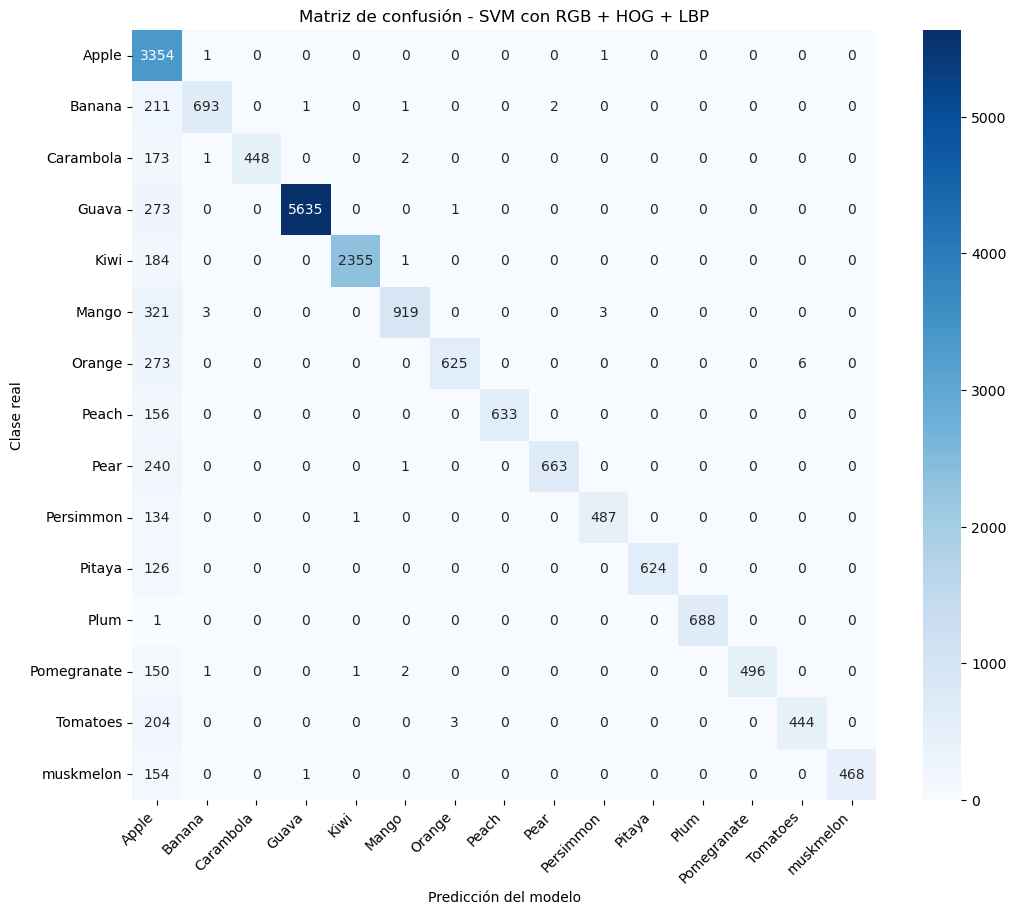

In [40]:
# ==============================
# BLOQUE 13 - Matriz de confusión del modelo SVM
# ==============================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenamos las etiquetas para que la matriz sea estable y fácil de leer
labels = sorted(np.unique(y_test))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Visualizamos la matriz de confusión
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels,
    cmap="Blues"
)

plt.xlabel("Predicción del modelo")
plt.ylabel("Clase real")
plt.title("Matriz de confusión - SVM con RGB + HOG + LBP")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig("Matriz_confusion_SVM.jpg")
plt.show()

## Conclusión del entrenamiento del modelo de SVM de Machine Learning

Dentro de los modelos de clasificaión de ML este es el modelo de SVM. En este modelo no se realizó el análisis de PCA ya que fue capaz de entrenarse sin el mismo, por lo que no se vió necesaria esta optimización, siendo que en el modelo de KNN se mantuvo alrededor del 90% del dato.

El modelo SVM busca la máxima separación de *features* entre clases, para ello durante el entrenamiento va alterando la linea que separa las diferentes clases hasta encontrar el máximo de separación. 

Para este problema de clasificación de imagenes como ML se han trabajado con 15 frutas distintas utilizando tres parámetros de las imagenes en forma de vector, el color, la forma y la textura. Todas estas características se han obtenido con la librería open_cv.

Para cada imagen se tenía al final un vector formado a partir de los tres vectores con más de 8000 parámetros por imagen. 

El resultado del modelo en términos generales es bueno, tenemos una exactitud del 87% y un f1-score global de 92%. Clasifica muy bien la mayoría de las frutas, eso, a grandes reasgos. Pero si vamos a mirar con más detalle la matriz de confusión vemos que la calidad del modelo no se reparte de forma equitativa. 

Tenemos frutas como el Plum que lo clasifica a la perfección, salvo una imagen que la etiqueta como manzana. Y aqui está el principal problema del modelo, debido a las *features* del dataset de entrenamiento, y a su composición al contener todas las manzanas, el modelo no ha sido capaz de separar bien esta clase del resto. Tenemos entre 126 y 321 imagenes de cada una de las 14 frutas (que no son manzanas) etiquetadas como manzanas. Esto equivale decir que, en los peroes casos, 1 de cada 3 frutas las etiqueta como manzana cuando no es manzana (ni Plum).

LA causa principal que se baraja es que las manzanas contiene mucho colores, por lo que este no es un carácter diferenciador para utilizarlo de forma óptima en SVM. Ya que el modelo no podrá separar bien esta característica del resto, que, es el parámetro que tiene el mayor tamaño en el vector que se utiliza para entrenar

Visto esto, el modelo debería volver a entrenarse, o bien, separando cada grupo de manzanas como una clase más o bien entrenando sin la matriz de color. Tambi{en se ha planteado usar un modelo doble, es decir, un modelo entrenado 1 vs all de manzanas frente al resto que si arroja un resultado de "manzana" de ese resultado pero que si da un resutlaod de "otra fruta" salte (como *input*) a un modelo entrenado como el anterior pero sin manzana.

No se ha ejecutado ninguna de estas acciones porque el modelo de DL ya es suficientemente bueno y permite una mejor clasificación.




--------

FUENTES

| Fuente oficial                                       | Qué justifica dentro del script                                                                                                                                                                                                                                                               |
| ---------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **OpenCV Documentation**                             | Lectura de imágenes con `cv2.imread`, conversión de color BGR/RGB/GRAY con `cv2.cvtColor`, redimensionado y extracción del histograma RGB con `cv2.calcHist`. OpenCV documenta la lectura de imágenes y sus herramientas generales de procesamiento de imagen. ([OpenCV-Python Tutorials][1]) |
| **scikit-image Documentation**                       | Uso de descriptores clásicos como **HOG** y **LBP** para extraer información de bordes, forma y textura. La documentación de scikit-image incluye `hog` y `local_binary_pattern`. ([Scikit-Image][2])                                                                                         |
| **scikit-learn Pipeline / Preprocessing / Modelado** | Construcción del flujo `StandardScaler → PCA → SVM`, usando `Pipeline` para encadenar transformaciones y modelo. ([Scikit-learn][3])                                                                                                                                                          |
| **scikit-learn Metrics**                             | Evaluación mediante `accuracy`, `classification_report` y `F1-score`. Scikit-learn documenta estas métricas para clasificación. ([Scikit-learn][4])                                                                                                                                           |

[1]: https://opencv24-python-tutorials.readthedocs.io/en/latest/py_tutorials/py_gui/py_image_display/py_image_display.html?utm_source=chatgpt.com "Getting Started with Images — OpenCV-Python Tutorials beta ..."
[2]: https://scikit-image.org/docs/0.25.x/api/skimage.feature.html?utm_source=chatgpt.com "skimage.feature — skimage 0.25.2 documentation"
[3]: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html?utm_source=chatgpt.com "Pipeline — scikit-learn 1.8.0 documentation"
[4]: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html?utm_source=chatgpt.com "accuracy_score — scikit-learn 1.8.0 documentation"
